#**스마트폰 센서 데이터 기반 모션 분류**
# 단계2 : 기본 모델링


## 0.미션3

* 데이터 전처리
    * 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리 수행
* 다양한 딥러닝 구조의 모델로 분류 모델 생성
    * 최소 4개 이상 모델링 수행
    * 각 모델별 최소 5회 반복수행해서 얻은 성능의 평균으로 비교
    * 각 모델의 성능을 저장하는 별도 데이터 프레임을 만들고 비교
* 옵션 : 다음 사항은 선택사항입니다. 시간이 허용하는 범위 내에서 수행하세요.
    * 상위 N개 변수를 선정하여 모델링 및 성능 비교
        * 모델링에 항상 모든 변수가 필요한 것은 아닙니다.
        * 변수 중요도 상위 N개를 선정하여 모델링하고 타 모델과 성능을 비교하세요.
        * 상위 N개를 선택하는 방법은, 변수를 하나씩 늘려가며 모델링 및 성능 검증을 수행하여 적절한 지점을 찾는 것입니다.
* 성능 가이드
    * Accuracy : 0.90 ~ 0.99

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Deep_Learning/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.regularizers import l1, l2

In [ ]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [ ]:
train_data = pd.read_csv(path + 'data01_train.csv')
test_data = pd.read_csv(path + 'data01_test.csv')
feature_data = pd.read_csv(path + 'features.csv')

In [ ]:
drop_cols = 'subject'

In [ ]:
train_data.drop(columns=drop_cols, inplace=True)
test_data.drop(columns=drop_cols, inplace=True)

#### 2) 기본 정보 조회

In [ ]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [ ]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


In [ ]:
train_data.shape

(5881, 562)

## **2. 데이터 전처리**

* 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리를 수행한다.


### (1) 데이터 분할1 : x, y

* 세부 요구사항
    - x, y로 분할합니다.

In [ ]:
target = 'Activity'

x = train_data.drop(columns=target)
y = train_data[target]

### (2) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [ ]:
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x)

### (3) Y 전처리
* integer encoding : LabelEncoder
* (필요시) one-hot encoding

In [ ]:
y.value_counts()

,count
Activity,
LAYING,1115
STANDING,1087
SITTING,1032
WALKING,998
WALKING_UPSTAIRS,858
WALKING_DOWNSTAIRS,791


In [ ]:
y = y.map({'LAYING':0, 'STANDING':1, 'SITTING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5})
y

,Activity
0,1
1,0
2,1
3,3
4,5
...,...
5876,2
5877,4
5878,0
5879,4


In [ ]:
from keras.utils import to_categorical

y_c = to_categorical(y.values, 6)

In [ ]:
y_c

array([[0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0.]])

### (4) 데이터분할2 : train, validation

* 세부 요구사항
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_scaled, y_c, test_size=0.3, random_state=1)

## **3. 기본 모델링**



* 세부 요구사항
    - 모델1 : Base line 모델
        * Hidden Layer 없이 모델 생성
    - 모델2 : 복잡한 모델 생성
        * 최소 5개 이상의 은닉층을 추가한 모델
    - 모델3 ~ n : 튜닝 모델
        * 학습률, epoch 등 조정
        * 모델2에 과적합을 방지하기 위한 규제 기법 추가
        * Accuracy 최대화 시키는 모델 생성하기
    - 각 모델은 최소 5번 반복수행해서 얻은 성능의 평균값을 기록

In [ ]:
nfeatures = x_train.shape[1]

nfeatures

561

### (1) 모델1

In [ ]:
clear_session()

model1 = Sequential([Input(shape=(nfeatures,)),
                     Dense(6, activation='softmax')])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │           3,372 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,372 (13.17 KB)

 Trainable params: 3,372 (13.17 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

result1 = model1.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history

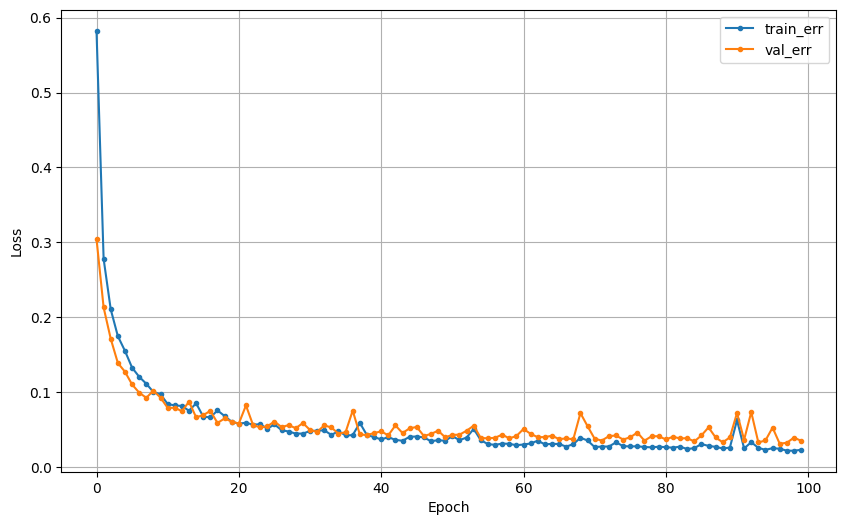

In [ ]:
dl_history_plot(result1)

In [ ]:
pred1 = model1.predict(x_val)

pred1 = np.argmax(pred1, axis=1)
y_val1 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val1, pred1))
print(confusion_matrix(y_val1, pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.98      0.93      0.95       331
           2       0.93      0.98      0.95       292
           3       1.00      1.00      1.00       297
           4       1.00      1.00      1.00       275
           5       1.00      0.99      1.00       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[331   0   0   0   0   0]
 [  0 308  23   0   0   0]
 [  0   7 285   0   0   0]
 [  0   0   0 297   0   0]
 [  0   0   0   0 275   0]
 [  0   0   0   1   1 237]]


### (1-1) 모델 1 반복 수행 후 평균, 표준편차 구하기

In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(6, activation='softmax')])

  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  result1 = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred1)
  accuracies.append(accuracy)

result = pd.DataFrame({'Baseline': accuracies})

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │           3,372 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,372 (13.17 KB)

 Trainable params: 3,372 (13.17 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │           3,372 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,372 (13.17 KB)

 Trainable params: 3,372 (13.17 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
result

,Baseline
0,0.976771
1,0.975637
2,0.977904
3,0.976204
4,0.977337


### (2) 모델2

In [ ]:
clear_session()

model2 = Sequential([Input(shape=(nfeatures,)),
                     Dense(128, activation='relu'),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(10, activation='relu'),
                     Dense(6, activation='softmax'),])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,036 (324.36 KB)

 Trainable params: 83,036 (324.36 KB)

 Non-trainable params: 0 (0.00 B)

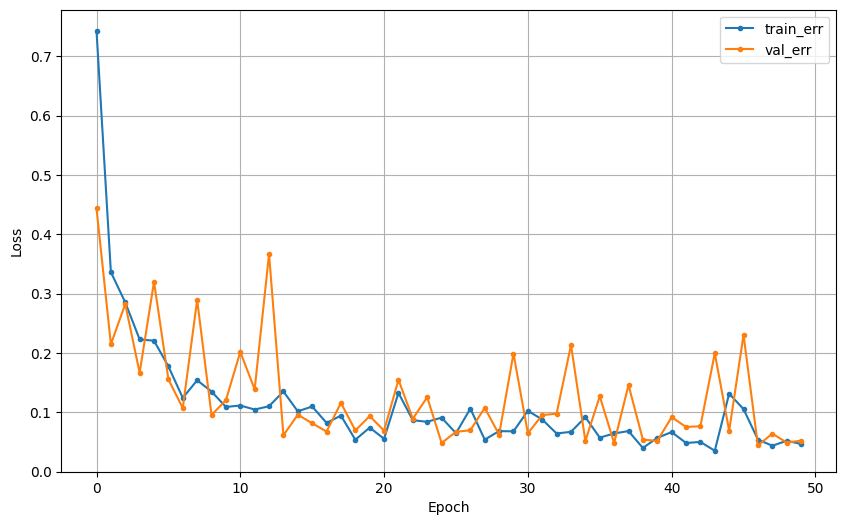

In [ ]:
model2.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

result2 = model2.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

dl_history_plot(result2)

In [ ]:
pred2 = model2.predict(x_val)
pred2 = np.argmax(pred2, axis=1)
y_val2 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
print(classification_report(y_val2, pred2))
print(confusion_matrix(y_val2, pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.93      0.98      0.95       331
           2       0.98      0.91      0.94       292
           3       1.00      1.00      1.00       297
           4       1.00      1.00      1.00       275
           5       1.00      0.99      1.00       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[331   0   0   0   0   0]
 [  0 325   6   0   0   0]
 [  1  26 265   0   0   0]
 [  0   0   0 297   0   0]
 [  0   0   0   0 275   0]
 [  0   0   0   1   1 237]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(128, activation='relu'),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(10, activation='relu'),
                     Dense(6, activation='softmax')])

  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  result1 = model.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['Dense'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,036 (324.36 KB)

 Trainable params: 83,036 (324.36 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,036 (324.36 KB)

 Trainable params: 83,036 (324.36 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
result

,Baseline,Dense
0,0.976771,0.981870
1,0.975637,0.933711
2,0.977904,0.979037
3,0.976204,0.980170
4,0.977337,0.972805


### (3) 모델3 - ShallowDense

In [ ]:
clear_session()

model3 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(8, activation='relu'),
                     Dense(6, activation='relu'),
                     Dense(6, activation='softmax'),])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              42 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,808 (151.59 KB)

 Trainable params: 38,808 (151.59 KB)

 Non-trainable params: 0 (0.00 B)

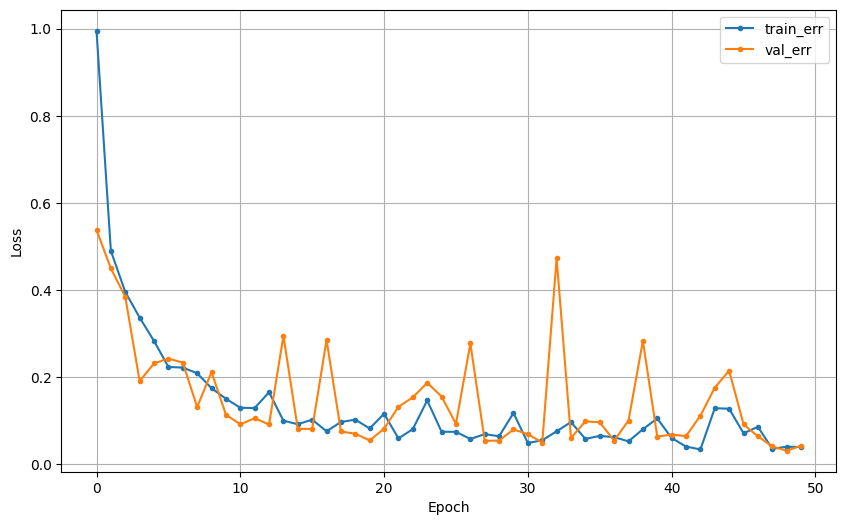

In [ ]:
model3.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

result3 = model3.fit(x_train, y_train, epochs=50, validation_split=.2, verbose=0).history

dl_history_plot(result3)

In [ ]:
pred3 = model3.predict(x_val)
pred3 = np.argmax(pred3, axis=1)
y_val3 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val3, pred3))
print(confusion_matrix(y_val3, pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.97      0.94      0.95       331
           2       0.94      0.96      0.95       292
           3       0.99      1.00      0.99       297
           4       0.99      1.00      0.99       275
           5       1.00      0.99      0.99       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[331   0   0   0   0   0]
 [  0 312  19   0   0   0]
 [  0  11 281   0   0   0]
 [  0   0   0 296   1   0]
 [  0   0   0   1 274   0]
 [  0   0   0   2   1 236]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(8, activation='relu'),
                     Dense(6, activation='relu'),
                     Dense(6, activation='softmax'),])

  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  result1 = model.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['ShallowDense'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              42 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,808 (151.59 KB)

 Trainable params: 38,808 (151.59 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              42 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,808 (151.59 KB)

 Trainable params: 38,808 (151.59 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
result

,Baseline,Dense,ShallowDense
0,0.976771,0.981870,0.960340
1,0.975637,0.933711,0.975637
2,0.977904,0.979037,0.956941
3,0.976204,0.980170,0.980737
4,0.977337,0.972805,0.967139


### (3) 모델3-1 - LessDense

In [ ]:
clear_session()

model3_1 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])

model3_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

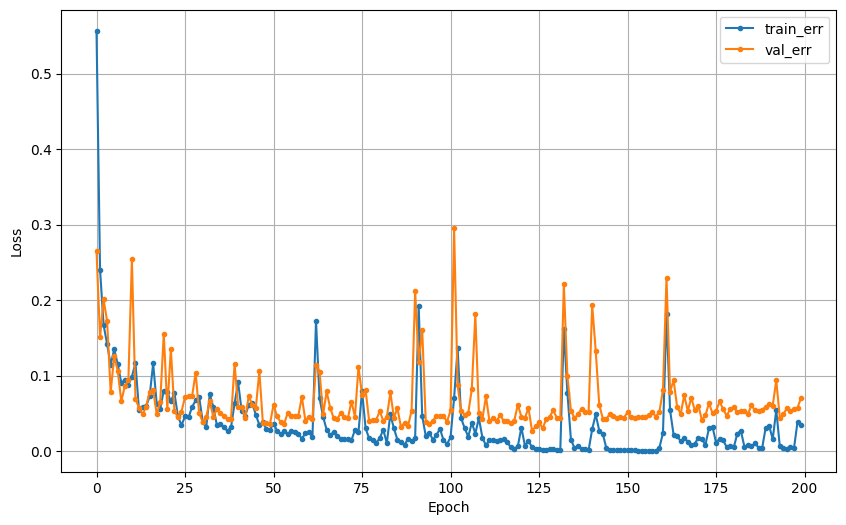

In [ ]:
model3_1.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

result3_1 = model3_1.fit(x_train, y_train, epochs=200, validation_split=.2, verbose=0).history

dl_history_plot(result3_1)

In [ ]:
pred3_1 = model3_1.predict(x_val)
pred3_1 = np.argmax(pred3_1, axis=1)
y_val3 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val3, pred3_1))
print(confusion_matrix(y_val3, pred3_1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.95      0.97      0.96       331
           2       0.97      0.94      0.96       292
           3       0.99      1.00      0.99       297
           4       0.99      1.00      0.99       275
           5       1.00      0.99      0.99       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[330   0   0   0   1   0]
 [  0 322   8   1   0   0]
 [  1  16 275   0   0   0]
 [  0   0   0 296   0   1]
 [  0   0   0   1 274   0]
 [  0   0   0   0   2 237]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])

  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  result1 = model.fit(x_train, y_train, epochs=200, validation_split=0.2, verbose=0).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['LessDense'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
result

,Baseline,Dense,ShallowDense,LessDense
0,0.976771,0.981870,0.960340,0.977904
1,0.975637,0.933711,0.975637,0.982436
2,0.977904,0.979037,0.956941,0.985269
3,0.976204,0.980170,0.980737,0.977337
4,0.977337,0.972805,0.967139,0.984136


### (4) 모델4 - EarlyStopping

In [ ]:
clear_session()

model4 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])

model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

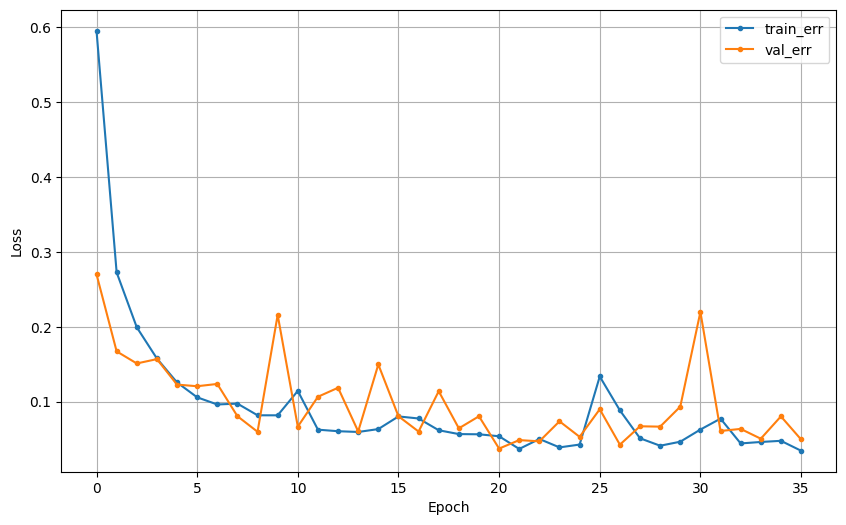

In [ ]:
from keras.callbacks import EarlyStopping

model4.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

min_de = 0.0001
pat = 15

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

result4 = model4.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0, callbacks=[es]).history

dl_history_plot(result4)

In [ ]:
pred4 = model4.predict(x_val)
pred4 = np.argmax(pred4, axis=1)
y_val4 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val4, pred4))
print(confusion_matrix(y_val4, pred4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.98      0.90      0.94       331
           2       0.89      0.98      0.94       292
           3       1.00      1.00      1.00       297
           4       0.99      1.00      0.99       275
           5       1.00      0.99      0.99       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[330   0   0   0   1   0]
 [  0 297  34   0   0   0]
 [  0   5 287   0   0   0]
 [  0   0   0 297   0   0]
 [  0   0   0   0 275   0]
 [  0   0   0   1   2 236]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])

  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  min_de = 0.0001
  pat = 15

  es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

  model4.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0, callbacks=[es])

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['EarlyStopping'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
result

,Baseline,Dense,ShallowDense,LessDense,EarlyStopping
0,0.976771,0.981870,0.960340,0.977904,0.959207
1,0.975637,0.933711,0.975637,0.982436,0.980170
2,0.977904,0.979037,0.956941,0.985269,0.980737
3,0.976204,0.980170,0.980737,0.977337,0.925212
4,0.977337,0.972805,0.967139,0.984136,0.964873


### (5) 모델5 - DropOut 실패

In [ ]:
clear_session()

model5 = Sequential([Input(shape=(nfeatures,)),
                     Dense(128, activation='relu'),
                     Dropout(0.5),
                     Dense(64, activation='relu'),
                     Dropout(0.5),
                     Dense(32, activation='relu'),
                     Dropout(0.5),
                     Dense(16, activation='relu'),
                     Dropout(0.5),
                     Dense(10, activation='relu'),
                     Dropout(0.5),
                     Dense(6, activation='softmax')])

model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,036 (324.36 KB)

 Trainable params: 83,036 (324.36 KB)

 Non-trainable params: 0 (0.00 B)

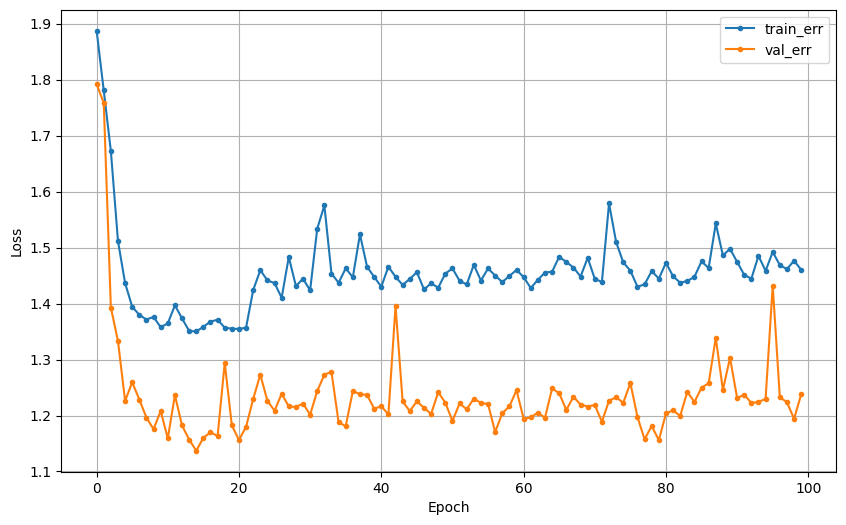

In [ ]:
model5.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

result5 = model5.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0).history

dl_history_plot(result5)

In [ ]:
pred5 = model5.predict(x_val)
pred5 = np.argmax(pred5, axis=1)
y_val5 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val5, pred5))
print(confusion_matrix(y_val5, pred5))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       331
           1       0.34      1.00      0.51       331
           2       0.00      0.00      0.00       292
           3       0.36      0.95      0.52       297
           4       0.00      0.00      0.00       275
           5       1.00      0.01      0.02       239

    accuracy                           0.35      1765
   macro avg       0.28      0.33      0.18      1765
weighted avg       0.26      0.35      0.19      1765

[[  0 331   0   0   0   0]
 [  0 331   0   0   0   0]
 [  0 292   0   0   0   0]
 [  0  14   0 283   0   0]
 [  0   8   0 267   0   0]
 [  0   0   0 236   0   3]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(501, activation='relu'),
                     Dense(251, activation='relu'),
                     Dense(101, activation='relu'),
                     Dense(51, activation='relu'),
                     Dense(21, activation='relu'),
                     Dense(6, activation='softmax'),])

  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  result1 = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['epochs'] = accuracies

### (6) 모델6 - Regularizer

In [ ]:
from keras.regularizers import l1

clear_session()

model6 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu', kernel_regularizer = l1(0.01)),
                     Dense(6, activation='softmax')])

model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

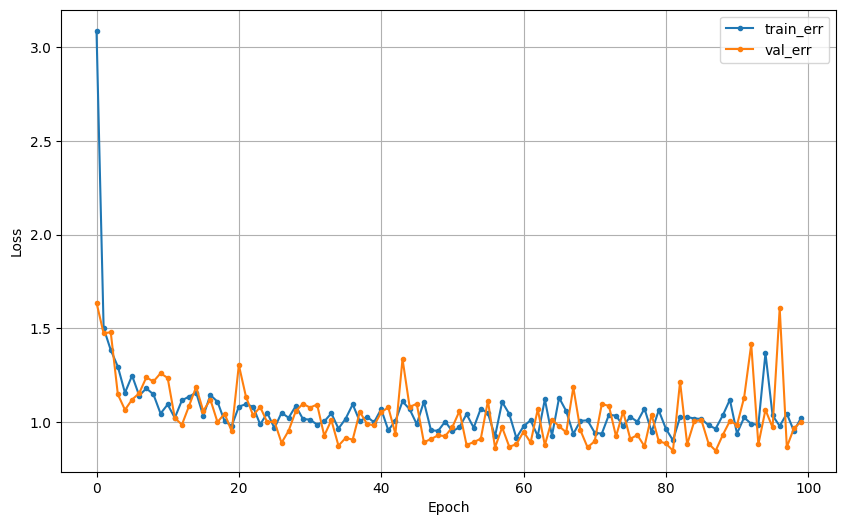

In [ ]:
model6.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

result6 = model6.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0).history

dl_history_plot(result6)

In [ ]:
pred6 = model6.predict(x_val)
pred6 = np.argmax(pred6, axis=1)
y_val6 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val6, pred6))
print(confusion_matrix(y_val6, pred6))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.79      0.98      0.88       331
           2       0.97      0.71      0.82       292
           3       0.95      0.99      0.97       297
           4       0.97      0.89      0.93       275
           5       0.89      0.95      0.92       239

    accuracy                           0.92      1765
   macro avg       0.93      0.92      0.92      1765
weighted avg       0.93      0.92      0.92      1765

[[331   0   0   0   0   0]
 [  0 323   6   2   0   0]
 [  0  84 207   0   1   0]
 [  0   0   0 293   1   3]
 [  0   0   0   6 244  25]
 [  0   0   0   8   5 226]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu', kernel_regularizer = l1(0.01)),
                     Dense(6, activation='softmax')])
  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  result1 = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['Regularizer'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
result

,Baseline,Dense,ShallowDense,LessDense,EarlyStopping,Regularizer
0,0.976771,0.981870,0.960340,0.977904,0.959207,0.856657
1,0.975637,0.933711,0.975637,0.982436,0.980170,0.912181
2,0.977904,0.979037,0.956941,0.985269,0.980737,0.886119
3,0.976204,0.980170,0.980737,0.977337,0.925212,0.887252
4,0.977337,0.972805,0.967139,0.984136,0.964873,0.907649


### (7) Extra Experiments

In [ ]:
clear_session()

model7 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])

model7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

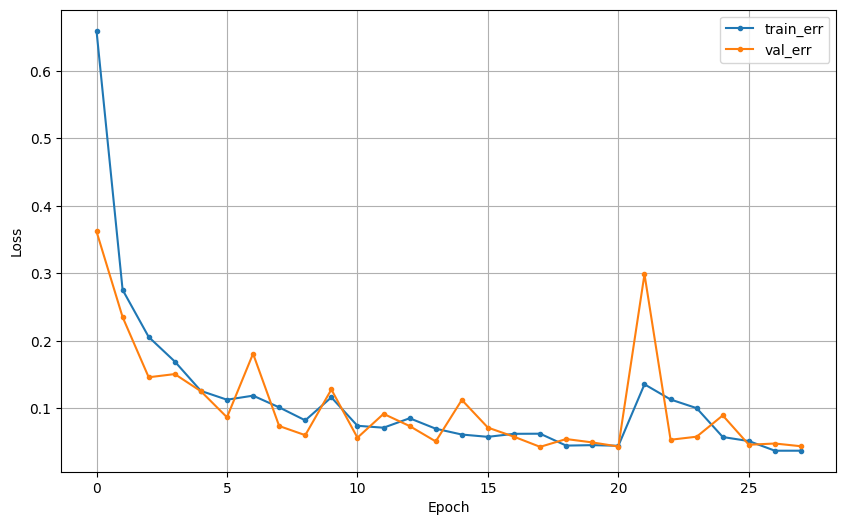

In [ ]:
model7.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

min_de = 0.0001
pat = 10

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

result7 = model7.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0, callbacks=[es]).history

# result7 = model7.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0).history

dl_history_plot(result7)

In [ ]:
pred7 = model7.predict(x_val)
pred7 = np.argmax(pred7, axis=1)
y_val7 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val7, pred7))
print(confusion_matrix(y_val7, pred7))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.93      0.98      0.95       331
           2       0.97      0.91      0.94       292
           3       0.98      1.00      0.99       297
           4       1.00      0.99      0.99       275
           5       1.00      0.99      0.99       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[331   0   0   0   0   0]
 [  0 324   7   0   0   0]
 [  1  25 266   0   0   0]
 [  0   0   0 297   0   0]
 [  0   0   0   3 272   0]
 [  0   0   0   3   0 236]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(6, activation='softmax')])
  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy')

  min_de = 0.0001
  pat = 10

  es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

  result1 = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['Extra'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,110 (144.96 KB)

 Trainable params: 37,110 (144.96 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,110 (144.96 KB)

 Trainable params: 37,110 (144.96 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
result

,Baseline,Dense,ShallowDense,LessDense,EarlyStopping,Regularizer,Early10
0,0.979037,0.980170,0.974504,0.979603,0.970538,0.885552,0.986969
1,0.976771,0.978470,0.977904,0.980737,0.969972,0.864589,0.987535
2,0.975637,0.974504,0.957507,0.976204,0.977904,0.842493,0.980170
3,0.976204,0.959207,0.979037,0.979603,0.980170,0.898584,0.984703
4,0.977904,0.933144,0.966572,0.977904,0.981870,0.893484,0.986969


In [ ]:
result.rename({'Extra':'Early10'}, axis=1, inplace=True)

### (7) Extra Experiments

In [ ]:
clear_session()

model8 = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])

model8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

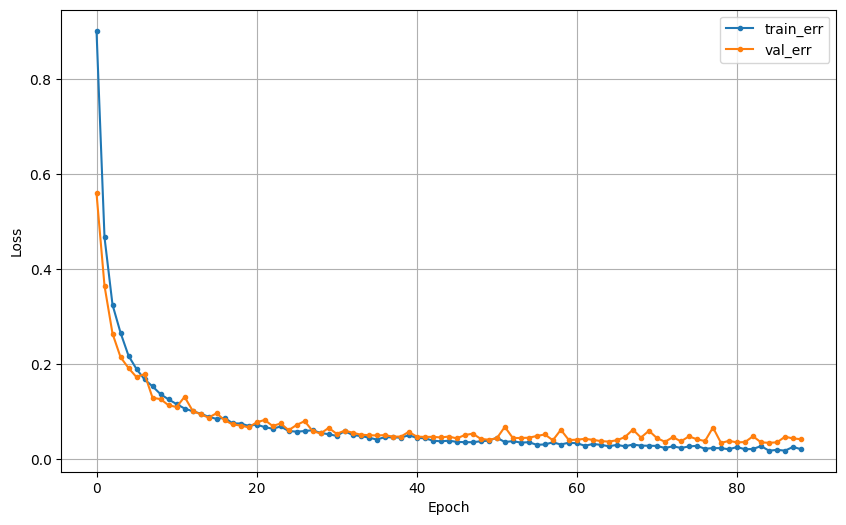

In [ ]:
model8.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')

min_de = 0.0001
pat = 10

es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

result8 = model8.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0, callbacks=[es]).history

# result7 = model7.fit(x_train, y_train, epochs=100, validation_split=.2, verbose=0).history

dl_history_plot(result8)

In [ ]:
pred8 = model8.predict(x_val)
pred8 = np.argmax(pred8, axis=1)
y_val8 = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val8, pred8))
print(confusion_matrix(y_val8, pred8))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.93      0.98      0.95       331
           2       0.98      0.91      0.94       292
           3       0.99      1.00      1.00       297
           4       1.00      1.00      1.00       275
           5       1.00      0.99      0.99       239

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765

[[331   0   0   0   0   0]
 [  0 325   6   0   0   0]
 [  1  25 266   0   0   0]
 [  0   0   0 297   0   0]
 [  0   0   0   0 275   0]
 [  0   0   0   2   1 236]]


In [ ]:
accuracies = []

for i in range(5):
  clear_session()

  model = Sequential([Input(shape=(nfeatures,)),
                     Dense(64, activation='relu'),
                     Dense(6, activation='softmax')])
  model.summary()

  model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')

  min_de = 0.0001
  pat = 10

  es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

  result1 = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=0, callbacks=[es]).history

  pred = model.predict(x_val)
  pred = np.argmax(pred, axis=1)
  y_val1 = np.argmax(y_val, axis=1)

  accuracy = accuracy_score(y_val1, pred)
  accuracies.append(accuracy)

result['LearningRate'] = accuracies

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
result

,Baseline,Dense,ShallowDense,LessDense,EarlyStopping,Regularizer,Early10,LearningRate
0,0.977337,0.956941,0.956374,0.972805,0.254958,0.913881,0.967705,0.976771
1,0.977337,0.621530,0.643626,0.986402,0.190368,0.887252,0.967705,0.974504
2,0.977337,0.972238,0.965439,0.977337,0.187535,0.809632,0.979037,0.976771
3,0.977337,0.970538,0.962606,0.976204,0.137110,0.932578,0.971671,0.972805
4,0.977337,0.965439,0.966006,0.983569,0.117847,0.922946,0.959773,0.980737


## 4.성능비교

In [ ]:
mean_std = result.agg(['mean', 'std'])
mean_std

,Baseline,Dense,ShallowDense,LessDense,EarlyStopping,Regularizer,Early10,LearningRate
mean,9.773371e-01,0.897337,0.898810,0.979263,0.177564,0.893258,0.969178,0.976317
std,1.241267e-16,0.154296,0.142703,0.005574,0.053516,0.049705,0.007004,0.002982


* 세부 요구사항
    - test 데이터에 대한 전처리
    - 각 모델에 대해서 test 데이터로 성능 측정

In [ ]:
target = 'Activity'

x_test = test_data.drop(columns=target)
y_test = test_data[target]

scaler = MinMaxScaler()

x_test_scaled = scaler.fit_transform(x_test)

y_test = y_test.map({'LAYING':0, 'STANDING':1, 'SITTING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5})

y_test_c = to_categorical(y_test.values, 6)

In [ ]:
list(result)

['Baseline',
 'Dense',
 'ShallowDense',
 'LessDense',
 'EarlyStopping',
 'Regularizer',
 'Early10',
 'LearningRate']

In [ ]:
models = [model1, model2, model3, model3_1, model4, model6, model7, model8]
acc = {}

for idx, val in enumerate(models):
  pred = val.predict(x_test_scaled)
  pred = np.argmax(pred, axis=1)
  y_test_c1 = np.argmax(y_test_c, axis=1)

  acc[list(result)[idx]] = accuracy_score(y_test_c1, pred)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
acc = pd.Series(acc)
acc.name = 'Accuracy'

acc

,Accuracy
Baseline,0.966010
Dense,0.927940
ShallowDense,0.947655
LessDense,0.968729
EarlyStopping,0.962610
Regularizer,0.876275
Early10,0.969409
LearningRate,0.956492


## 변수 선정 후 모델링

In [ ]:
features = joblib.load(path+'merged_features.pkl')

In [ ]:
features[:10]['Feature'].values

array(['tGravityAcc-mean()-X', 'tGravityAcc-energy()-X',
       'angle(X,gravityMean)', 'tGravityAcc-mean()-Y',
       'tGravityAcc-max()-X', 'angle(Y,gravityMean)',
       'tGravityAcc-min()-Y', 'tGravityAcc-max()-Y',
       'tGravityAcc-min()-X', 'fBodyAccJerk-bandsEnergy()-1,24'],
      dtype=object)

In [ ]:
selected_features = features[:40]['Feature'].values
x_s = train_data[selected_features]
y_s = train_data['Activity']

In [ ]:
x_train_s, x_val_s, y_train_s, y_val_s = train_test_split(x_s, y_c, test_size=0.3, random_state=1)

In [ ]:
model = Sequential([
    Input(shape=(len(selected_features),)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')

result_s = model.fit(x_train_s, y_train_s, epochs=100, validation_split=0.2, verbose=0).history

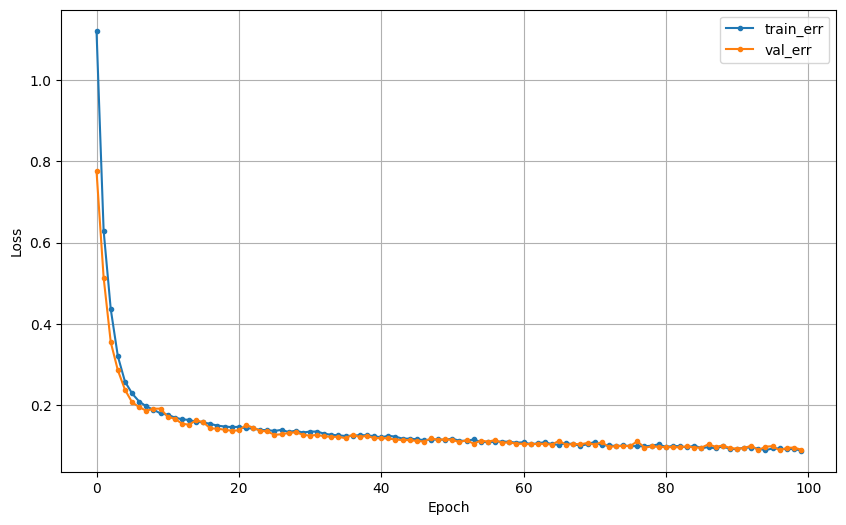

In [ ]:
dl_history_plot(result_s)

In [ ]:
pred_s = model.predict(x_val_s)
pred_s = np.argmax(pred_s, axis=1)
y_val_s = np.argmax(y_val, axis=1)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val_s, pred_s))
print(confusion_matrix(y_val_s, pred_s))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.90      0.86      0.88       331
           2       0.85      0.89      0.87       292
           3       0.99      0.99      0.99       297
           4       1.00      0.99      0.99       275
           5       0.99      1.00      0.99       239

    accuracy                           0.95      1765
   macro avg       0.95      0.95      0.95      1765
weighted avg       0.95      0.95      0.95      1765

[[331   0   0   0   0   0]
 [  0 285  46   0   0   0]
 [  0  33 259   0   0   0]
 [  0   0   0 295   1   1]
 [  0   0   0   2 271   2]
 [  0   0   0   1   0 238]]
